In [191]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

In [192]:
df = pd.read_csv("data.csv")
df.sample(5)

,Age,Income,Salary,Rating,Annual_Income,Customer_Support_Calls,House_Price,Square_Feet,Temperature,City,Product_Type,Location,Diagnosis,Cabin,Embarked,Gender,Target,Price_Target
677,56.0,NaN,41435,4.3,104070.0,1.0,132823.0,1681,21.8,Dhaka,A,B,Type3,Cabin_D,C,Female,0,212.78
796,34.0,NaN,59203,5.0,NaN,1.0,199937.0,1924,Unknown,Dhaka,A,C,Type1,NaN,S,Male,0,201.69
178,31.0,19802.0,68334,4.5,59794.0,2.0,NaN,2457,Unknown,Khulna,B,B,Type3,Cabin_D,S,Female,0,266.65
125,61.0,35386.0,93469,3.8,80463.0,5.0,206899.0,2069,24.2,NaN,A,B,Type3,NaN,Q,Male,0,178.70
19,18.0,51581.0,36237,2.1,87840.0,3.0,505984.0,2568,16.7,Khulna,B,C,Type3,NaN,S,Female,0,292.59


---
---

## **Problem 1**

In [193]:
df.isnull().sum()

Age                       180
Income                    150
Salary                      0
Rating                     80
Annual_Income             120
Customer_Support_Calls     80
House_Price               100
Square_Feet                 0
Temperature                50
City                       50
Product_Type                0
Location                    0
Diagnosis                 220
Cabin                     680
Embarked                    2
Gender                      0
Target                      0
Price_Target                0
dtype: int64

In [194]:
missing_percentage = (df.isnull().sum()/df.isnull().value_counts().sum()) * 100
missing_percentage

Age                       18.0
Income                    15.0
Salary                     0.0
Rating                     8.0
Annual_Income             12.0
Customer_Support_Calls     8.0
House_Price               10.0
Square_Feet                0.0
Temperature                5.0
City                       5.0
Product_Type               0.0
Location                   0.0
Diagnosis                 22.0
Cabin                     68.0
Embarked                   0.2
Gender                     0.0
Target                     0.0
Price_Target               0.0
dtype: float64

In [195]:
missing_percentage.loc[missing_percentage>50]

Cabin    68.0
dtype: float64

---

## **Problem 2**

In [196]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Age                     820 non-null    float64
 1   Income                  850 non-null    float64
 2   Salary                  1000 non-null   int64  
 3   Rating                  920 non-null    float64
 4   Annual_Income           880 non-null    float64
 5   Customer_Support_Calls  920 non-null    float64
 6   House_Price             900 non-null    float64
 7   Square_Feet             1000 non-null   int64  
 8   Temperature             950 non-null    str    
 9   City                    950 non-null    str    
 10  Product_Type            1000 non-null   str    
 11  Location                1000 non-null   str    
 12  Diagnosis               780 non-null    str    
 13  Cabin                   320 non-null    str    
 14  Embarked                998 non-null    str    
 15 

In [197]:
df["Temperature"].value_counts()

Temperature
Unknown    65
23.1       13
21.0       12
20.2       12
21.3       11
           ..
10.8        1
18.1        1
17.3        1
12.5        1
32.4        1
Name: count, Length: 203, dtype: int64

In [198]:
df["Temperature"] = df["Temperature"].replace(["Unknown", "NaN"], np.nan)
df["Temperature"] = df["Temperature"].astype("float64")
df.sample(10)

,Age,Income,Salary,Rating,Annual_Income,Customer_Support_Calls,House_Price,Square_Feet,Temperature,City,Product_Type,Location,Diagnosis,Cabin,Embarked,Gender,Target,Price_Target
14,14.0,4175.0,88517,3.6,40286.0,3.0,162792.0,1690,14.5,Dhaka,A,A,Type2,Cabin_G,S,Male,0,281.44
167,57.0,53624.0,50193,4.7,89262.0,3.0,187923.0,1760,23.4,Khulna,C,A,Type1,NaN,S,Male,0,268.49
457,22.0,13800.0,36536,4.3,92467.0,1.0,346854.0,2115,15.8,Chittagong,C,A,Type2,NaN,S,Male,0,247.76
966,26.0,111524.0,53012,4.5,69102.0,4.0,-13851.0,2023,26.3,Rajshahi,B,B,Type1,Cabin_F,S,Male,0,277.59
313,44.0,NaN,72268,NaN,76806.0,NaN,305821.0,1542,22.3,Chittagong,A,B,Type3,NaN,Q,Female,0,214.64
429,13.0,3215.0,63988,4.9,88958.0,1.0,346107.0,1507,28.5,NaN,B,A,Type3,NaN,C,Female,0,207.57
967,56.0,NaN,57737,3.1,NaN,1.0,286301.0,2347,29.9,Chittagong,B,A,NaN,NaN,C,Female,0,253.06
212,46.0,46812.0,57553,3.8,116084.0,3.0,128232.0,1261,30.0,Khulna,B,B,NaN,Cabin_C,S,Female,0,186.69
388,46.0,NaN,47472,2.7,70615.0,1.0,377622.0,2332,18.5,Dhaka,C,A,Type2,Cabin_F,S,Female,0,255.49
810,32.0,97308.0,50899,2.7,68061.0,3.0,184454.0,2022,24.4,Chittagong,B,B,Type3,NaN,S,Male,0,226.83


---

## **Problem 3**

In [199]:
df.drop(["Embarked", "Cabin", "Rating", "Customer_Support_Calls", "Product_Type", "Target"],axis=1, inplace=True)
df.sample(5)

,Age,Income,Salary,Annual_Income,House_Price,Square_Feet,Temperature,City,Location,Diagnosis,Gender,Price_Target
411,21.0,12169.0,60287,35858.0,NaN,1717,22.0,Chittagong,C,Type3,Male,322.29
150,38.0,58984.0,63806,106237.0,172963.0,1461,23.7,Dhaka,B,NaN,Female,223.76
959,40.0,42405.0,55550,67872.0,NaN,1632,24.8,NaN,B,Type2,Female,318.99
968,34.0,46708.0,58890,61631.0,185805.0,1781,23.7,Chittagong,A,Type3,Female,309.02
524,25.0,11513.0,55189,76108.0,NaN,1190,14.8,Rajshahi,B,Type2,Female,234.31


In [200]:
X = df.drop(["House_Price"], axis=1)
y = df["House_Price"]

In [201]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, train_size=0.8, random_state=42)

In [202]:
diagnosis_imputer = SimpleImputer(missing_values = np.nan, strategy = "constant", fill_value = "Missing", add_indicator = True)
diagnosis_imputer.fit(X_train[["Diagnosis"]])

X_train[["Diagnosis", "diagnosis_missing_indicator"]] = diagnosis_imputer.transform(X_train[["Diagnosis"]])
X_test[["Diagnosis", "diagnosis_missing_indicator"]] = diagnosis_imputer.transform(X_test[["Diagnosis"]])

In [203]:
display(X_train.sample(5))
X_test.sample(5)

,Age,Income,Salary,Annual_Income,Square_Feet,Temperature,City,Location,Diagnosis,Gender,Price_Target,diagnosis_missing_indicator
368,36.0,242413.0,41097,99754.0,2415,17.6,Rajshahi,C,Type3,Female,297.16,False
671,10.0,22489.0,63591,41671.0,1883,24.4,Khulna,A,Type1,Female,205.35,False
14,14.0,4175.0,88517,40286.0,1690,14.5,Dhaka,A,Type2,Male,281.44,False
886,42.0,1687.0,63906,87006.0,1505,21.5,Khulna,C,Type2,Female,242.51,False
686,32.0,30641.0,48210,107374.0,3025,25.4,Khulna,A,Missing,Male,288.49,True


,Age,Income,Salary,Annual_Income,Square_Feet,Temperature,City,Location,Diagnosis,Gender,Price_Target,diagnosis_missing_indicator
901,NaN,99962.0,36966,51248.0,1850,24.6,Chittagong,A,Type1,Female,276.29,False
198,NaN,46247.0,74296,NaN,2560,NaN,Rajshahi,A,Type2,Male,215.17,False
221,12.0,114154.0,47743,59252.0,2567,21.0,Khulna,C,Type2,Male,256.24,False
494,53.0,8135.0,34112,127329.0,2263,25.3,Dhaka,A,Type1,Male,267.12,False
76,36.0,96339.0,71902,74823.0,1234,14.9,Dhaka,B,Missing,Male,265.23,True


---

## **Problem 4**

In [204]:
print(f"X_train avg age: {X_train["Age"].mean()}")
print(f"X_train median age: {X_train["Age"].median()}")

X_train avg age: 34.6338880484115
X_train median age: 34.0


In [205]:
age_mean_imputer = SimpleImputer(missing_values = np.nan, strategy = "mean")
age_mean_imputer.fit(X_train[["Age"]])

X_train["age_mean_imputed"] = age_mean_imputer.transform(X_train[["Age"]]).ravel()
X_test["age_mean_imputed"] = age_mean_imputer.transform(X_test[["Age"]]).ravel()

In [206]:
age_median_imputer = SimpleImputer(missing_values = np.nan, strategy = "median")
age_median_imputer.fit(X_train[["Age"]])

X_train["age_median_imputed"] = age_median_imputer.transform(X_train[["Age"]]).ravel()
X_test["age_median_imputed"] = age_median_imputer.transform(X_test[["Age"]]).ravel()

<Axes: xlabel='age_mean_imputed', ylabel='Density'>

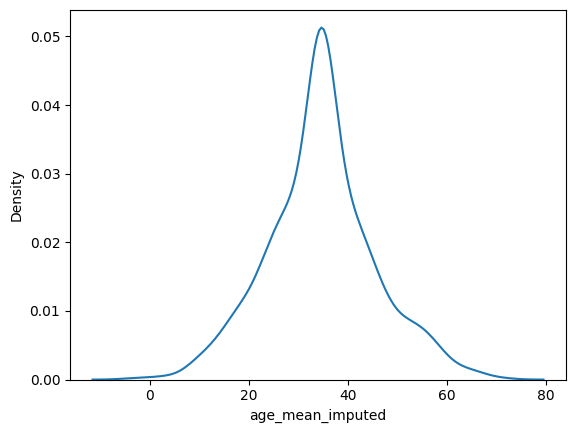

In [207]:
sns.kdeplot(x=X_train["age_mean_imputed"])

<Axes: xlabel='age_median_imputed', ylabel='Density'>

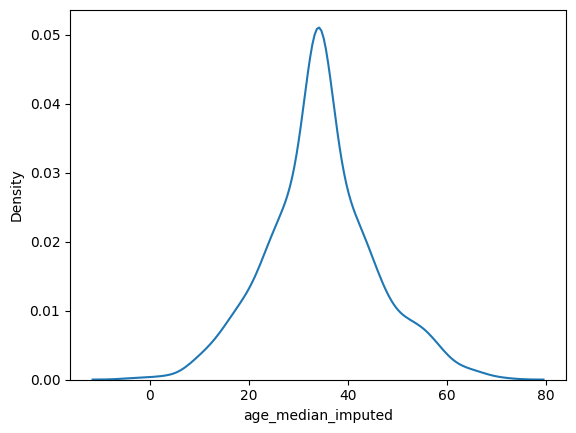

In [208]:
sns.kdeplot(x=X_train["age_median_imputed"])

In [209]:
display(X_train["Age"].std())
display(X_train["age_mean_imputed"].std())
X_train["age_median_imputed"].std()

np.float64(11.861153867659603)

np.float64(10.780167723873225)

np.float64(10.782846245492998)